# Descripción

- age: Edad del paciente.

- sex: Sexo del paciente.

- cp: Tipo de dolor torácico experimentado.

- trestbps: Presión arterial en reposo al ingreso en el hospital.

- chol: Medición del colesterol sérico.

- fbs: Indicador de si el azúcar en sangre en ayunas es superior a 120 mg/dl.

- restecg: Resultados del electrocardiograma en reposo.

- thalach: Frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo.

- exang: Presencia de angina inducida por el ejercicio.

- oldpeak: Depresión del segmento ST inducida por el ejercicio relative al reposo.

- slope: La pendiente del segmento ST durante el ejercicio pico.

- ca: Número de vasos principales visibles por fluoroscopia.

- thal: Un tipo de talasemia o resultado de una prueba de esfuerzo con talio.

- num: Diagnóstico de enfermedad cardíaca (variable objetivo).

# Carga e identificación

## Librerías

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, classification_report, 
                            confusion_matrix, roc_curve, roc_auc_score)
from ucimlrepo import fetch_ucirepo

## Carga del dataset

In [44]:
heart_disease = fetch_ucirepo(id=45) 
  
# Cargar dataset
heart_disease = fetch_ucirepo(id=45) 

# Crear un solo dataframe uniendo features y target
df = pd.concat([heart_disease.data.features, heart_disease.data.targets], axis=1)
  
  
'''  # metadata 
print(heart_disease.metadata)
# variable information 
print(heart_disease.variables) '''

'  # metadata \nprint(heart_disease.metadata)\n# variable information \nprint(heart_disease.variables) '

In [45]:
df.shape

(303, 14)

In [46]:
df.head() 

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [47]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

## Identificando NAs

=== Resumen de valores nulos ===
          Nulos  Porcentaje (%)
age           0            0.00
sex           0            0.00
cp            0            0.00
trestbps      0            0.00
chol          0            0.00
fbs           0            0.00
restecg       0            0.00
thalach       0            0.00
exang         0            0.00
oldpeak       0            0.00
slope         0            0.00
ca            4            1.32
thal          2            0.66
num           0            0.00


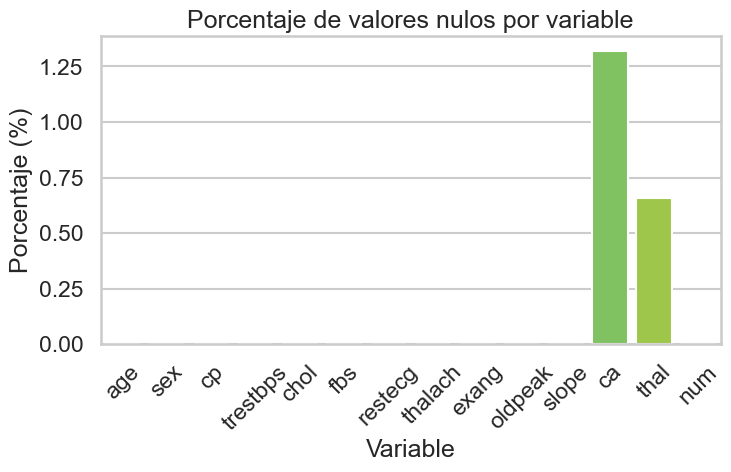

In [48]:
total = len(df)
null_counts = df.isna().sum()
null_percent = (null_counts / total) * 100


missing_summary = pd.DataFrame({
    "Nulos": null_counts,
    "Porcentaje (%)": null_percent.round(2)
})

print("=== Resumen de valores nulos ===")
print(missing_summary)


plt.figure(figsize=(8,4))
sns.barplot(x=missing_summary.index, y=missing_summary["Porcentaje (%)"], hue=missing_summary.index, palette="viridis", legend=False)
plt.title("Porcentaje de valores nulos por variable")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.show()

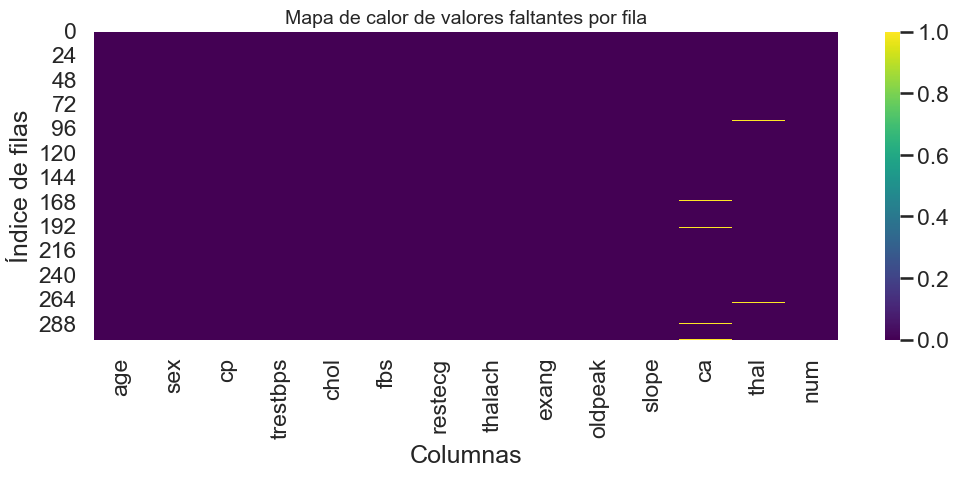

In [49]:
# --- Mapa de calor por filas ---
missing_matrix = df.isnull()
plt.figure(figsize=(12,4))
sns.heatmap(missing_matrix, cmap="viridis", cbar=True, xticklabels=True)
plt.title("Mapa de calor de valores faltantes por fila", fontsize=14)
plt.xlabel("Columnas")
plt.ylabel("Índice de filas")
plt.show()

Nuestro dataset contienemente unicamente valores de NA unicamente en dos variables y con un porcentaje menor al 1.5% así que simplemente imputaremos por moda las filas con valores faltantes pues no introducirá sesgo significativo para nuestro análisis y modelado.

In [50]:
df = df.fillna({
    'ca': df['ca'].mode()[0],
    'thal': df['thal'].mode()[0]
})
print(df.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


## Estudio de predictores 

In [51]:
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
X = df.drop("num", axis=1)
y = df["num"]

# Suponiendo X = variables, y = objetivo categórico
selector = SelectKBest(score_func=mutual_info_classif, k=6)
X_new = selector.fit_transform(X, y)

# Ver qué variables quedaron
selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'], dtype='object')


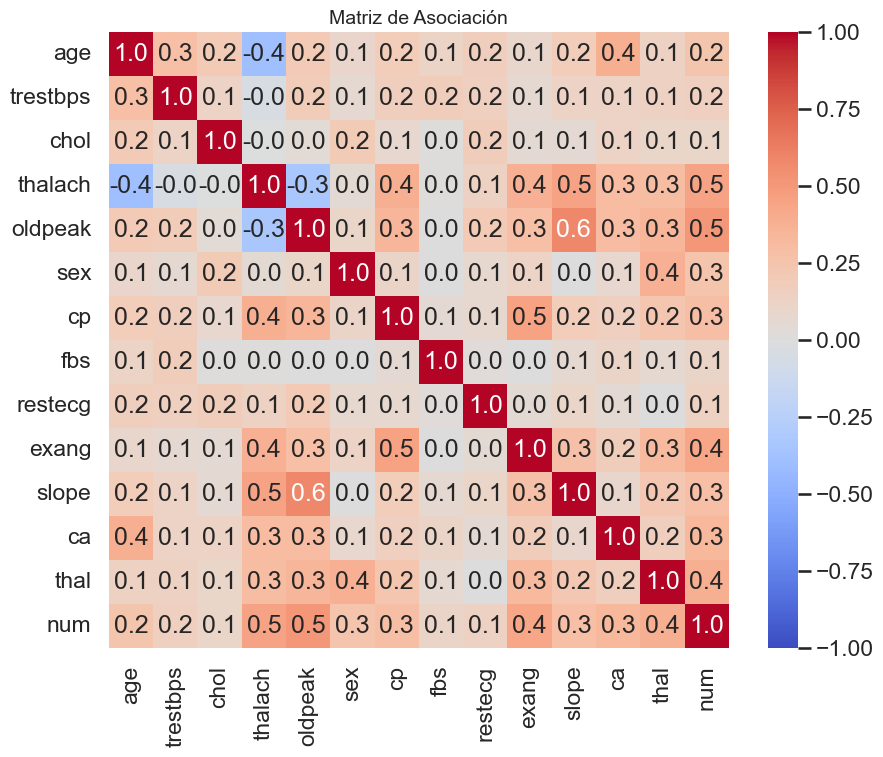

In [ ]:
# ---- Funciones auxiliares ----
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def correlation_ratio(categories, values):
    fcat, _ = pd.factorize(categories)
    values = np.array(values)
    cat_num = np.max(fcat) + 1
    y_avg = np.mean(values)
    
    numerator = sum([
        len(values[fcat == i]) * (np.mean(values[fcat == i]) - y_avg)**2
        for i in range(cat_num)
    ])
    denominator = np.sum((values - y_avg)**2)
    
    return np.sqrt(numerator/denominator) if denominator != 0 else 0


# ---- Definir variables ----
num_vars = ["age","trestbps","chol","thalach","oldpeak"]
cat_vars = ["sex","cp","fbs","restecg","exang","slope","ca","thal","num"]

# ---- Matriz de asociación ----
cols = num_vars + cat_vars
assoc_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for i in cols:
    for j in cols:
        if i == j:
            assoc_matrix.loc[i, j] = 1.0
        elif (i in num_vars) and (j in num_vars):
            assoc_matrix.loc[i, j] = np.corrcoef(df[i], df[j])[0,1]
        elif (i in cat_vars) and (j in cat_vars):
            assoc_matrix.loc[i, j] = cramers_v(df[i], df[j])
        else:
            num_col = i if i in num_vars else j
            cat_col = j if i in num_vars else i
            assoc_matrix.loc[i, j] = correlation_ratio(df[cat_col], df[num_col])

# ---- Heatmap ----
plt.figure(figsize=(10,8))
sns.heatmap(
    assoc_matrix.astype(float),
    annot=True,
    fmt=".1f",  
    cmap="coolwarm",
    vmin=-1, vmax=1, center=0
)
plt.title("Matriz de Asociación", fontsize=14)
plt.show()

En base a nuestro estudio de de predictores  tenemos una primer aproximación de los vairalbes más influyentes en nuestra variable objetivo, por lo que hemos decidido usar las varibles: 'sex', 'exang', 'cp', 'oldpeak' y además 'age', 'cho' para la realización del EDA

# EDA

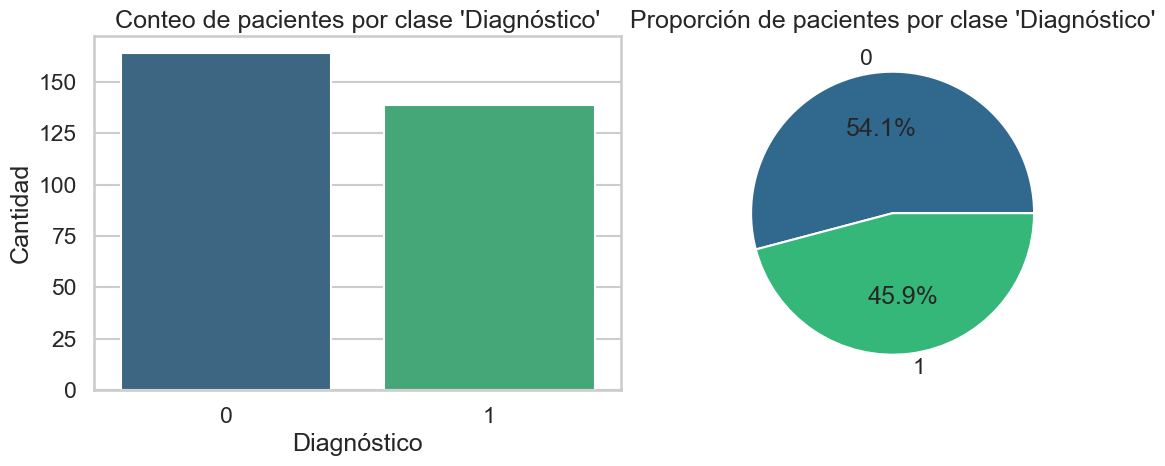

In [65]:
df = df.rename(columns={'num': 'target'})
num_counts = df['target'].value_counts()
num_labels = num_counts.index

plt.figure(figsize=(12,5))

# 1️⃣ Countplot
plt.subplot(1,2,1)
sns.countplot(x='target', data=df, hue='target', palette='viridis', legend=False)
plt.title("Conteo de pacientes por clase 'Diagnóstico'")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad")

# 2️⃣ Pie chart
plt.subplot(1,2,2)
plt.pie(num_counts, labels=num_labels, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(num_counts)))
plt.title("Proporción de pacientes por clase 'Diagnóstico'")

plt.tight_layout()
plt.show()

Observamos que más del 50% de nuestra población se encuentra sana y no padece de cardiopatía. Solo el 4.3% (al rededor de 12) de las personas padecen de cardiopatía grave. Y casi el 20% se encuentra con cardiopatía con el nivel más bajo de gravedad, este es el tipo de cardiopatía más frecuente entre las personas de nuetro estudio.

Debido a la baja proporción de personas diagnosticadas con cardiopatía, agruparemos las clases '1', '2', '3', y '4'.
Nuestra variable objetivo cuenta con 5 categorías:
- 0 si está sana
- 1, 2, 3 y 4 indican la gravedad de la cardiopatía (Entre más alto más grave).

Simplificaremos dicha variable para indicar:

- 0 si está sana
- 1 si padece cardiopatía

In [54]:
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

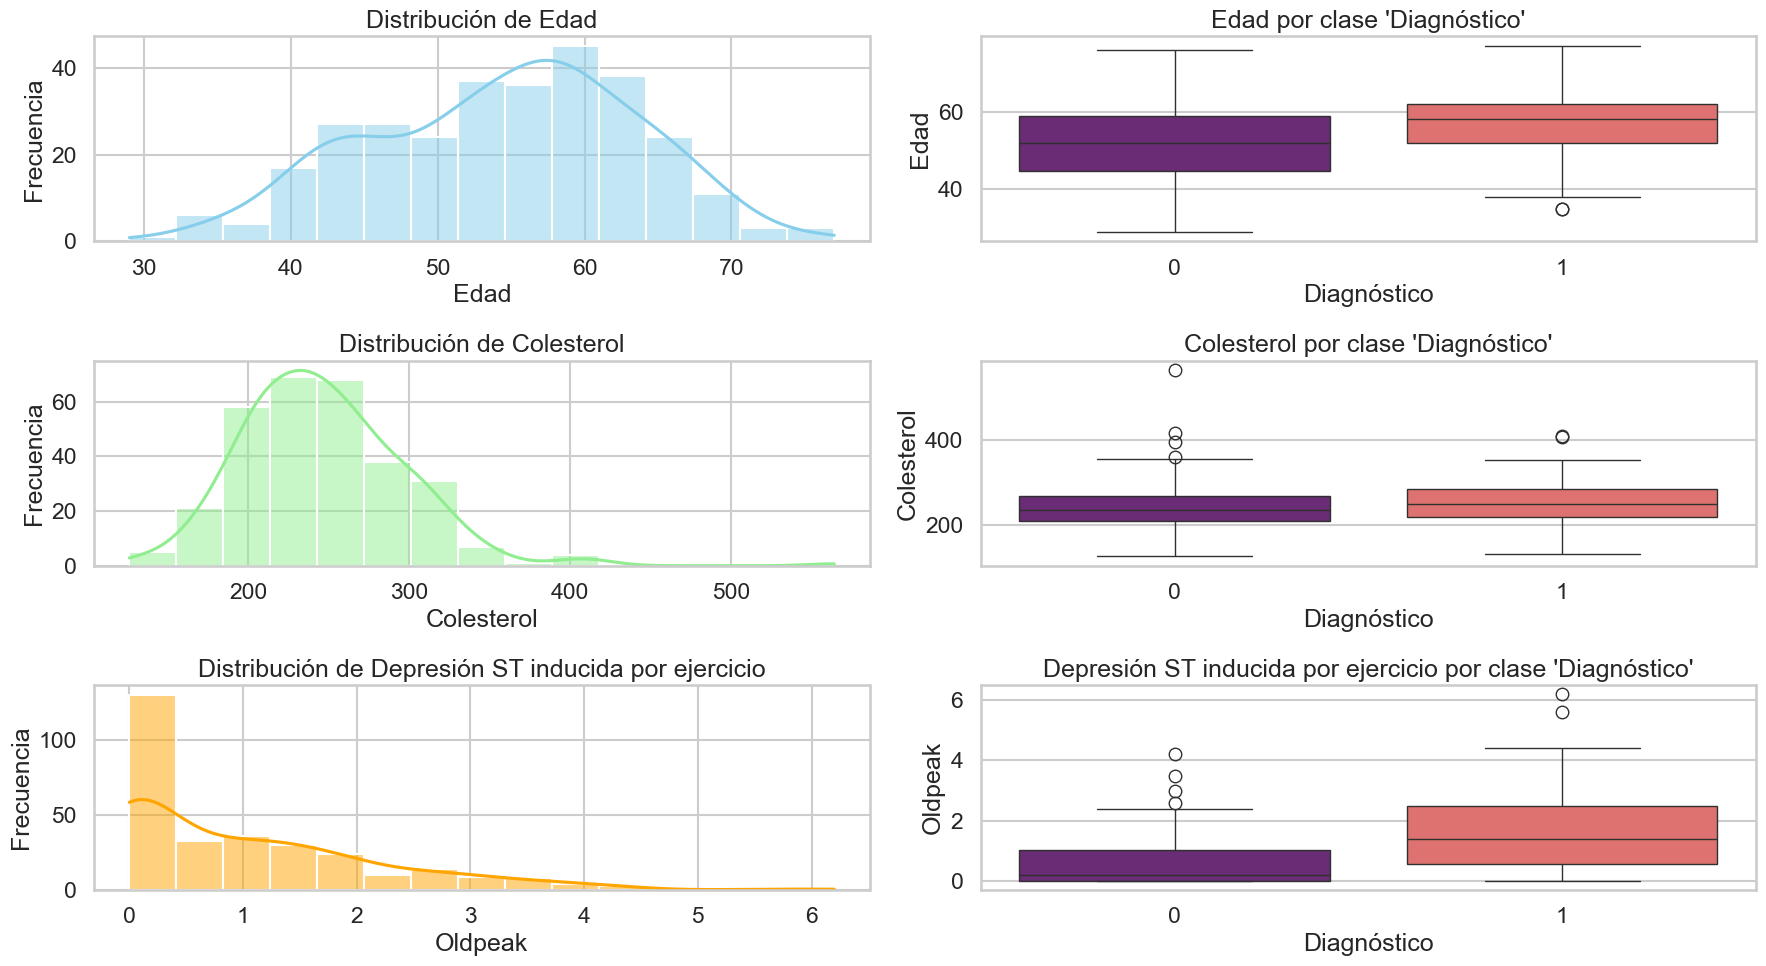

In [55]:
fig, axes = plt.subplots(3, 2, figsize=(18,10))

# =========================
# BLOQUE 1: Age
# =========================
sns.histplot(df['age'], bins=15, kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].set_title("Distribución de Edad")
axes[0,0].set_xlabel("Edad")
axes[0,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='age', data=df, hue='target', palette='magma', ax=axes[0,1], legend=False)
axes[0,1].set_title("Edad por clase 'Diagnóstico'")
axes[0,1].set_xlabel("Diagnóstico")
axes[0,1].set_ylabel("Edad")

# =========================
# BLOQUE 2: Cholesterol
# =========================
sns.histplot(df['chol'], bins=15, kde=True, color='lightgreen', ax=axes[1,0])
axes[1,0].set_title("Distribución de Colesterol")
axes[1,0].set_xlabel("Colesterol")
axes[1,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='chol', data=df, hue='target', palette='magma', ax=axes[1,1], legend=False)
axes[1,1].set_title("Colesterol por clase 'Diagnóstico'")
axes[1,1].set_xlabel("Diagnóstico")
axes[1,1].set_ylabel("Colesterol")

# Gráfico 3: Oldpeak
sns.histplot(df['oldpeak'], bins=15, kde=True, color='orange', ax=axes[2,0])
axes[2,0].set_title("Distribución de Depresión ST inducida por ejercicio")
axes[2,0].set_xlabel("Oldpeak")
axes[2,0].set_ylabel("Frecuencia")

sns.boxplot(x='target', y='oldpeak', data=df, hue='target', palette='magma', ax=axes[2,1], legend=False)
axes[2,1].set_title("Depresión ST inducida por ejercicio por clase 'Diagnóstico'")
axes[2,1].set_xlabel("Diagnóstico")
axes[2,1].set_ylabel("Oldpeak")

plt.tight_layout()
plt.show()



- Age: Nuestra población de edad se encuentra concentrada mayormente entre los 50 y 65 años aproximadamente, siento las edades que tienden por la izquierda a 60 con mayor representación. Además encontramos que para las personas diagnosticadas con cardiopatía suelen tener más de 40 años, pero esto puede ser por la poca representación de personas menores de 40 años en el estudio
- Colesterol: Para el colesterol tenemos los valores concentrados aproximadamente entre 100 y 350 aproximadamente, contando con raras ocasiones donde una persona tiene el colesterol por más de 350. Además, para las personas que padecen cardiopatía la mitad de estas personas tiene ligeramente mayores niveles de coesterol, aunque no hay grande variabilidad entre las personas que padecen colesterol y las que no.
- Oldpeak: 
Observamos que la depresión del segmento ST inducida por el ejercicio en relación con el reposo, tiene un sesgo hacía la derecha. Siento la moda de este valor entre 0 y 0.3. Además, para las personas que padecen cardiopatía son más probables a tener mayor depresión en el segmento ST inducida por el ejercicio respecto al reposo.

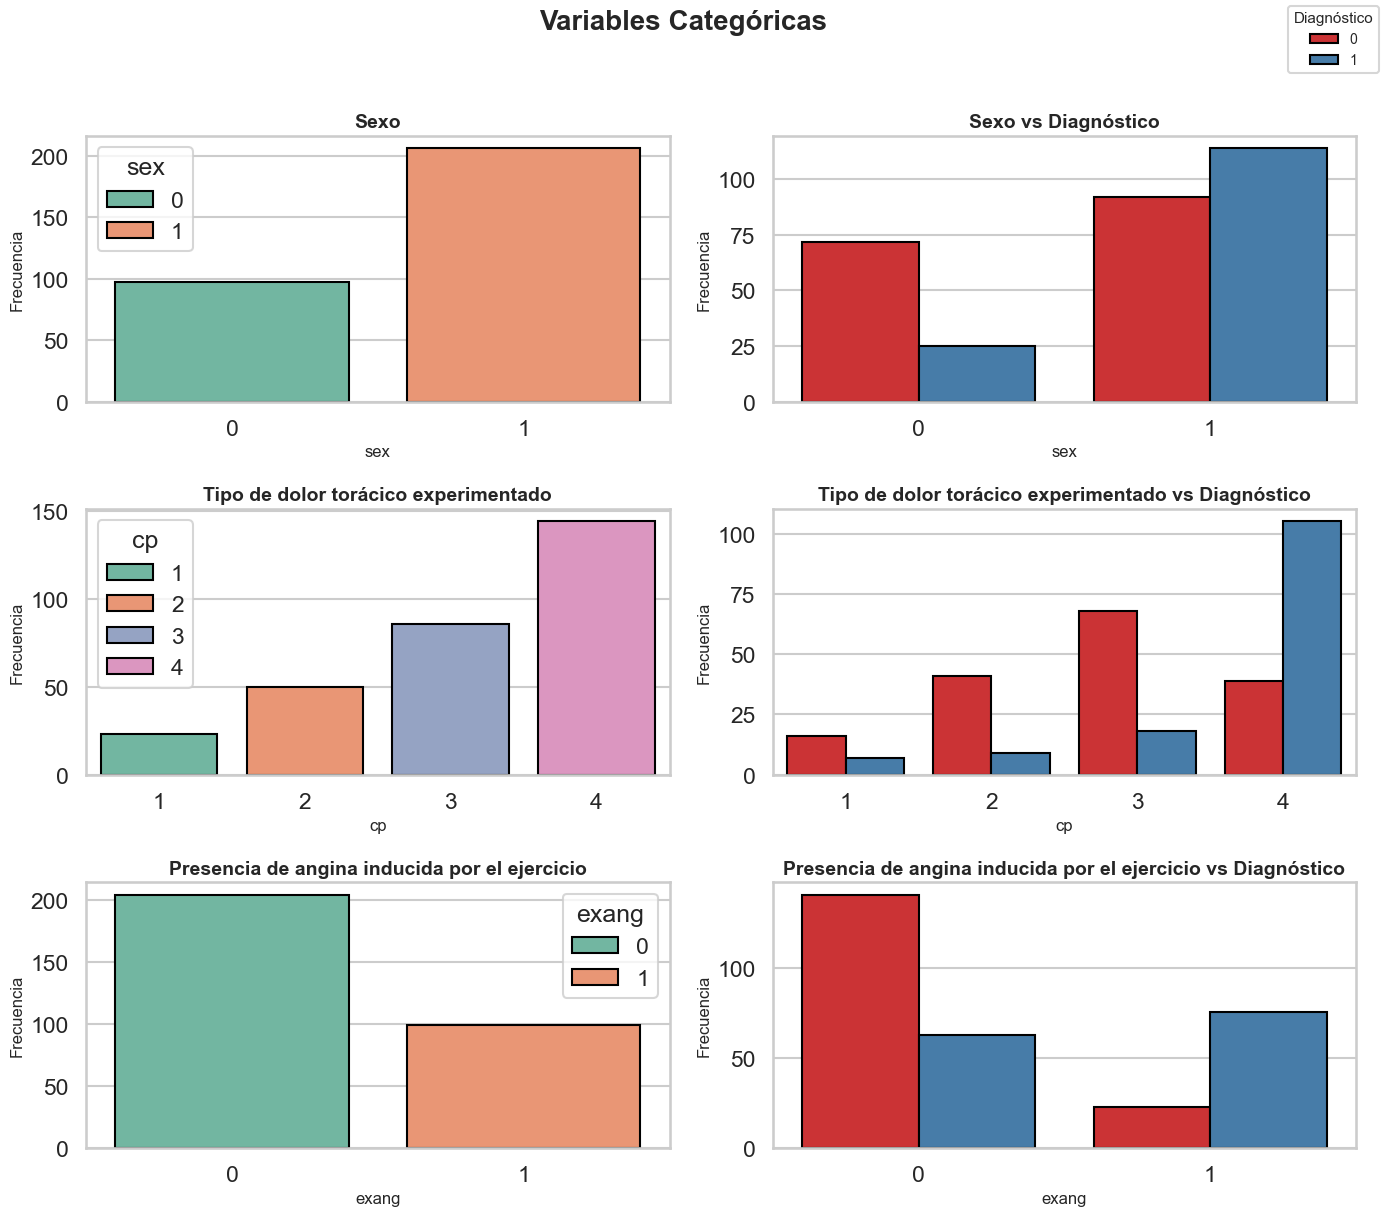

In [56]:
categorical_vars = ['sex', 'cp', 'exang']

descriptions = {
    'sex': "Sexo",
    'cp': "Tipo de dolor torácico experimentado",
    'exang': "Presencia de angina inducida por el ejercicio",
}

sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(len(categorical_vars), 2, figsize=(14, 12))
fig.suptitle("Variables Categóricas", fontsize=20, fontweight="bold", y=1.02)

# Variable para guardar handles y labels de la primera vez
legend_handles, legend_labels = None, None

for i, var in enumerate(categorical_vars):
    # Distribución simple (columna izquierda)
    sns.countplot(
        data=df, x=var, ax=axes[i,0], hue = var, palette="Set2", edgecolor="black"
    )
    axes[i,0].set_title(f"{descriptions.get(var, var)}", fontsize=14, fontweight="bold")
    axes[i,0].set_xlabel(var, fontsize=12)
    axes[i,0].set_ylabel("Frecuencia", fontsize=12)

    # Relación con target (columna derecha)
    ax = sns.countplot(
        data=df, x=var, hue='target', ax=axes[i,1], palette="Set1", edgecolor="black"
    )
    axes[i,1].set_title(f"{descriptions.get(var, var)} vs Diagnóstico", fontsize=14, fontweight="bold")
    axes[i,1].set_xlabel(var, fontsize=12)
    axes[i,1].set_ylabel("Frecuencia", fontsize=12)

    # Guardar handles y labels de la primera vez
    if legend_handles is None and legend_labels is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # Eliminar leyenda local
    ax.legend_.remove()

# Crear leyenda global usando los handles capturados
fig.legend(legend_handles, legend_labels, title="Diagnóstico", loc="upper right", fontsize=10, title_fontsize=11, frameon=True)

plt.tight_layout()
plt.show()



- Sex: Observamos que dentro del estudio existe el doble de mujeres que de hombres. Además que es más probable que una mujer padezca cardiopatía, pero esto puede ser sesgado por la diferencia en la clase mayoritaria de las mujeres.
- Tipo de dolor toracico (cp): El tipo de dolor toracico más experimentado es el tipo 4 y a su vez las personas, que padecen de este dolor con mayor frecuencia padecen cardiopatía tambien. Mientras que para los otros tipo de dolores, es menos probable que padezcan cardiopatia en base a este dolor.
- Presencia de angina inducida por ejercicio (Exang): En nuestra muestra existe el doble de personas que no tuvieran presencia de angina durante el ejercicio. Además, podemos notar que si una persona tiene la presencia de esta angina durante el ejercicio es más probable que padezca de cardiopatía.

# Preprocesamiento

In [57]:
categorical_vars = ['cp', 'exang', 'slope', 'thal', 'ca']
numeric_vars = ['oldpeak', 'age', 'trestbps', 'chol', 'thalach']
target = "target"

X = df[categorical_vars + numeric_vars]
y = df[target]

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [58]:


# Preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_vars),
        ("num", StandardScaler(), numeric_vars)
    ]
)


# Modelo

In [59]:
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', GaussianNB())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8852459016393442

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61


Matriz de confusión:
 [[27  6]
 [ 1 27]]


In [60]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')

print("=== Validación cruzada ===")
print("Accuracy promedio:", cv_scores.mean().round(3))
print("Desviación estándar:", cv_scores.std().round(3))

=== Validación cruzada ===
Accuracy promedio: 0.828
Desviación estándar: 0.025


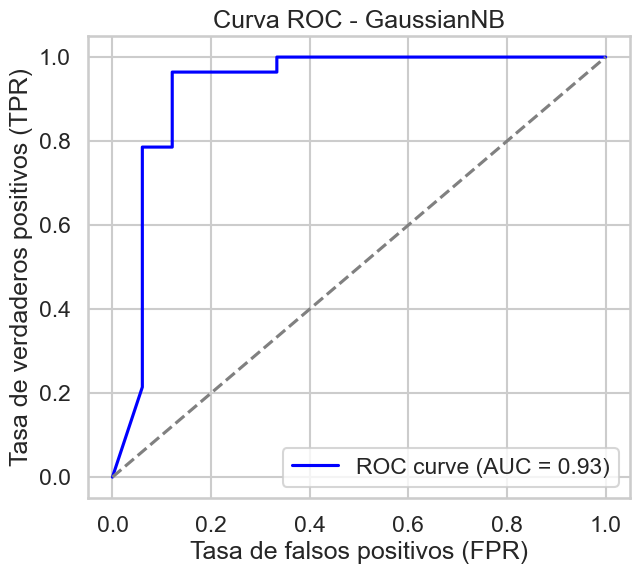

In [61]:
# Probabilidades de predicción en test
y_proba = pipeline.predict_proba(X_test)[:, 1]  # solo la clase positiva
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - GaussianNB')
plt.legend(loc="lower right")
plt.show()

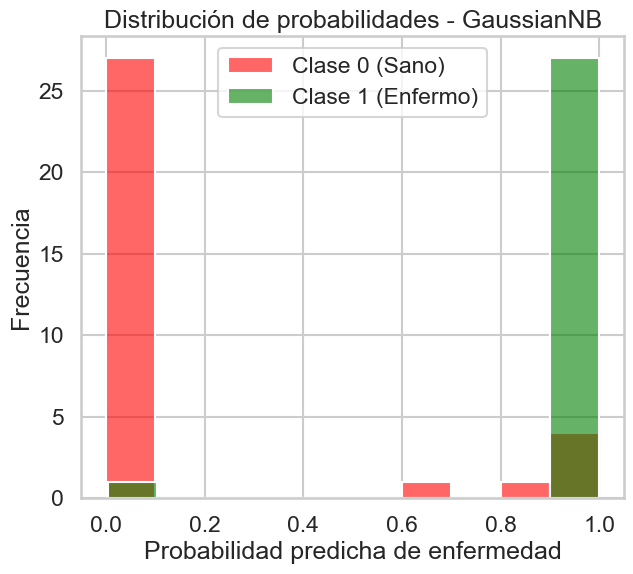

In [62]:
# Distribución de probabilidades predichas
plt.figure(figsize=(7, 6))
sns.histplot(y_proba[y_test == 0], bins=10, color='red', alpha=0.6, label='Clase 0 (Sano)')
sns.histplot(y_proba[y_test == 1], bins=10, color='green', alpha=0.6, label='Clase 1 (Enfermo)')
plt.xlabel("Probabilidad predicha de enfermedad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades - GaussianNB")
plt.legend()
plt.show()